In [1]:
import os
os.chdir('../..')

In [2]:
import selfies as sf
from scipy.spatial.distance import cosine, euclidean
from utils.load_datasets import QM9Loader
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

/Users/karlfindhansen/Desktop/DTU/Kandidat/Thesis/Anomaly-Detection-in-Molecular-and-Materials-Datasets/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
qm9 = QM9Loader()

# Morgan Fingerprints

In [4]:
df_morgan_fingerprint = qm9.get_morgan_fingerprints(radius=3, fp_size=2048)

2026-02-10 10:56:10.665 | WARNING  | utils.load_datasets:get_morgan_fingerprints:322 - DataFrame is empty. Loading data first...
2026-02-10 10:56:10.672 | INFO     | utils.load_datasets:load_data:108 - Found existing QM9 dataset at data/QM9/dataset_cleaned.csv. Loading with Polars...
2026-02-10 10:56:10.701 | INFO     | utils.load_datasets:load_data:121 - Found existing Grassmann Stress Test at data/QM9/stress_test_perturbations.xyz. Skipping generation.
2026-02-10 10:56:10.707 | INFO     | utils.load_datasets:get_morgan_fingerprints:325 - Computing Morgan Fingerprints (Radius=3, Size=2048)...


In [5]:
df_morgan = df_morgan_fingerprint['morgan_fingerprint']
df_morgan_list = list(df_morgan)

validating that it has done it correct. 

In [6]:
for _, ls in enumerate(df_morgan_list[0:4]):
    for i, val in enumerate(ls):
        if val == 1:
            print(i)

1264
930
790
915
1119


# Validate One-Hot and Transformer embeddings

In [7]:
df = qm9.get_selfies_embeddings()

2026-02-10 10:56:13.920 | INFO     | utils.load_datasets:get_selfies_embeddings:438 - Computing One-Hot Encodings...
2026-02-10 10:56:14.331 | INFO     | utils.load_datasets:get_selfies_embeddings:441 - Computing Transformer Embeddings...
2026-02-10 10:56:14.331 | INFO     | utils.load_datasets:_generate_selfies_transformer:385 - Loading Transformer model: seyonec/ChemBERTa-zinc-base-v1...
Loading weights: 100%|██████████| 103/103 [00:00<00:00, 1442.11it/s, Materializing param=pooler.dense.weight]                             
RobertaModel LOAD REPORT from: seyonec/ChemBERTa-zinc-base-v1
Key                       | Status     |  | 
--------------------------+------------+--+-
lm_head.dense.weight      | UNEXPECTED |  | 
lm_head.dense.bias        | UNEXPECTED |  | 
lm_head.decoder.bias      | UNEXPECTED |  | 
lm_head.layer_norm.bias   | UNEXPECTED |  | 
lm_head.layer_norm.weight | UNEXPECTED |  | 
lm_head.decoder.weight    | UNEXPECTED |  | 
lm_head.bias              | UNEXPECTED |  | 



In [8]:
df

mol_id,name,original_smiles,canonical_smiles,selfies,num_atoms,mu,alpha,homo,lumo,gap,r2,zpve,u0,u,h,g,cv,u0_atom,u_atom,h_atom,g_atom,A,B,C,morgan_fingerprint,selfies_onehot,selfies_transformer
str,str,str,str,str,i64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,list[i8],list[list[i64]],list[f64]
"""qm9_0""","""CH4""","""[H]C([H])([H])[H]""","""C""","""[C]""",5,0.0,13.21,-10.549854,3.186453,13.736308,35.364101,1.217682,-1101.487793,-1101.40979,-1101.384033,-1102.022949,6.469,-17.172182,-17.286823,-17.389656,-16.151918,157.711807,157.709976,157.706985,"[0, 0, … 0]","[[0, 0, … 0], [0, 0, … 1], … [0, 0, … 1]]","[1.116855, 0.998924, … 0.737373]"
"""qm9_1""","""H3N""","""[H]N([H])[H]""","""N""","""[N]""",4,1.6256,9.46,-6.993326,2.255824,9.249149,26.1563,0.934929,-1538.147705,-1538.069824,-1538.044189,-1538.666748,6.316,-12.005855,-12.082129,-12.159273,-11.246005,293.609741,293.541107,191.393967,"[0, 0, … 0]","[[0, 0, … 0], [0, 0, … 1], … [0, 0, … 1]]","[0.316447, 0.69667, … 1.264199]"
"""qm9_2""","""H2O""","""[H]O[H]""","""O""","""[O]""",3,1.8511,6.31,-7.967494,1.869422,9.836916,19.0002,0.581643,-2079.077881,-2079.000732,-2078.975098,-2079.558105,6.002,-9.240362,-9.278811,-9.330214,-8.733849,799.588135,437.90387,282.945465,"[0, 0, … 0]","[[0, 0, … 0], [0, 0, … 1], … [0, 0, … 1]]","[0.08437, 0.681181, … 0.699162]"
"""qm9_3""","""C2H2""","""[H]C#C[H]""","""C#C""","""[C][#C]""",4,0.0,16.280001,-7.741639,1.376896,9.118535,59.524799,0.730381,-2103.669434,-2103.590576,-2103.564697,-2104.186523,8.574,-16.716963,-16.792231,-16.869347,-15.862634,0.0,35.610035,35.610035,"[0, 0, … 0]","[[0, 0, … 0], [1, 0, … 0], … [0, 0, … 1]]","[0.895405, 0.401674, … 0.650952]"
"""qm9_4""","""CHN""","""[H]C#N""","""C#N""","""[C][#N]""",3,2.8937,12.99,-9.806983,0.519737,10.329442,48.747601,0.451736,-2541.866943,-2541.79834,-2541.772705,-2542.393555,6.278,-13.088188,-13.13529,-13.186666,-12.520096,0.0,44.593884,44.593884,"[0, 0, … 0]","[[0, 0, … 0], [0, 1, … 0], … [0, 0, … 1]]","[0.981024, 0.386095, … 1.052694]"
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""qm9_2010""","""C5H7NO""","""[H]C1=C([H])C([H])([H])C([H])(…","""O=C1C=CCCN1""","""[O][=C][C][=C][C][C][N][Ring1]…",14,4.175,59.880001,-6.511684,-0.854437,5.657247,680.8172,3.166589,-8833.507812,-8833.344727,-8833.319336,-8834.314453,22.622999,-60.986275,-61.363506,-61.697636,-56.969707,5.0588,2.61575,1.79821,"[0, 0, … 0]","[[0, 0, … 0], [0, 0, … 0], … [0, 0, … 1]]","[0.299405, -0.013913, … 1.102453]"
"""qm9_2011""","""C5H6O2""","""[H]C1=C([H])C([H])([H])C([H])(…","""O=C1C=CCCO1""","""[O][=C][C][=C][C][C][O][Ring1]…",13,4.8544,56.209999,-7.159316,-1.257166,5.90215,655.236389,2.820787,-9374.298828,-9374.142578,-9374.116211,-9375.104492,21.473,-58.082684,-58.426769,-58.735184,-54.355564,5.15103,2.69583,1.85565,"[0, 0, … 0]","[[0, 0, … 0], [0, 0, … 0], … [0, 0, … 1]]","[0.233892, 0.030704, … 1.002681]"
"""qm9_2012""","""C5H10NO-""","""[H][N-][C@@H]1OC([H])([H])C([H…","""[NH-][C@H]1CCCCO1""","""[NH1-1][C@H1][C][C][C][C][O][R…",16,3.2084,62.029999,-6.908971,0.634025,7.542996,719.927979,3.796587,-8865.521484,-8865.349609,-8865.324219,-8866.344727,23.990999,-65.773956,-66.218506,-66.604065,-61.192863,4.58056,2.56496,1.77558,"[0, 0, … 0]","[[0, 0, … 0], [0, 0, … 0], … [0, 0, … 1]]","[0.537106, -0.137771, … 0.598195]"


In [9]:
onehot_matrix = df["selfies_onehot"][0]

print(f"Number of tokens (Sequence Length): {len(onehot_matrix)}")
print(f"Vocabulary Size (Tokens in alphabet): {len(onehot_matrix[0])}")

is_valid = all(sum(row) == 1 for row in onehot_matrix)
print(f"Is strictly one-hot: {is_valid}")

smiles = df["canonical_smiles"][0] # e.g., "C"
selfie_str = sf.encoder(smiles)    # e.g., "[C]"
print(f"SELFIES: {selfie_str}")
print(f"Tokens: {list(sf.split_selfies(selfie_str))}") # Should match matrix row count (plus padding)

Number of tokens (Sequence Length): 15
Vocabulary Size (Tokens in alphabet): 39
Is strictly one-hot: True
SELFIES: [C]
Tokens: ['[C]']


In [10]:
transformer_vec = df["selfies_transformer"][0]
print(f"Embedding dimension: {len(transformer_vec)}") # Should be 768

vec_0 = df["selfies_transformer"][0]
vec_1 = df["selfies_transformer"][1]

# Check if they are actually different
print(f"Are vectors identical? {vec_0 == vec_1}")

# Similarity = 1 - distance
similarity = 1 - cosine(df["selfies_transformer"][0], df["selfies_transformer"][1])
print(f"Similarity between first two molecules: {similarity}")

Embedding dimension: 768
Are vectors identical? shape: (768,)
Series: '' [bool]
[
	false
	false
	false
	false
	false
	…
	false
	false
	false
	false
	false
]
Similarity between first two molecules: 0.7993101949537702


In [11]:
import polars as pl

# Check for nulls
null_counts = df.select([
    pl.col("selfies_onehot").is_null().sum().alias("onehot_nulls"),
    pl.col("selfies_transformer").is_null().sum().alias("transformer_nulls")
])
print(null_counts)

# Check if any transformer vectors are all zeros (indicating a failure in the model pass)
all_zeros = all(v == 0 for v in df["selfies_transformer"][0])
print(f"Is first transformer vector empty/zeros? {all_zeros}")

shape: (1, 2)
┌──────────────┬───────────────────┐
│ onehot_nulls ┆ transformer_nulls │
│ ---          ┆ ---               │
│ u32          ┆ u32               │
╞══════════════╪═══════════════════╡
│ 0            ┆ 0                 │
└──────────────┴───────────────────┘
Is first transformer vector empty/zeros? False


# Distance metrics
## Morgan (Jaccard)

In [12]:
def plot_distance_heatmaps(dist_morgan, dist_selfies, subset_size=100):
    """
    Plots heatmaps for Morgan and SELFIES distance matrices.
    """
    fig, axes = plt.subplots(1, 2, figsize=(16, 7))

    # 1. Morgan (Jaccard) Heatmap
    sns.heatmap(
        dist_morgan[:subset_size, :subset_size], 
        ax=axes[0], 
        cmap="magma", 
        cbar_kws={'label': 'Jaccard Distance'}
    )
    axes[0].set_title(f"Morgan Fingerprints (First {subset_size})")
    axes[0].set_xlabel("Molecule Index")
    axes[0].set_ylabel("Molecule Index")

    # 2. SELFIES (Euclidean) Heatmap
    sns.heatmap(
        dist_selfies[:subset_size, :subset_size], 
        ax=axes[1], 
        cmap="magma", 
        cbar_kws={'label': 'Euclidean Distance'}
    )
    axes[1].set_title(f"SELFIES Transformer (First {subset_size})")
    axes[1].set_xlabel("Molecule Index")
    axes[1].set_ylabel("Molecule Index")

    plt.tight_layout()
    #plt.savefig("distance_comparison_heatmap.png")
    plt.show()

In [13]:
distance_morgan = qm9.get_dist_matrix(distance_type='morgan')
distance_morgan

2026-02-10 10:56:29.842 | INFO     | utils.load_datasets:get_dist_matrix:496 - Loading existing morgan distance matrix from data/QM9/dist_matrix_morgan.npy...


array([[0.        , 1.        , 1.        , ..., 1.        , 1.        ,
        1.        ],
       [1.        , 0.        , 1.        , ..., 1.        , 1.        ,
        1.        ],
       [1.        , 1.        , 0.        , ..., 1.        , 1.        ,
        1.        ],
       ...,
       [1.        , 1.        , 1.        , ..., 0.        , 0.62962963,
        0.68965517],
       [1.        , 1.        , 1.        , ..., 0.62962963, 0.        ,
        0.74193548],
       [1.        , 1.        , 1.        , ..., 0.68965517, 0.74193548,
        0.        ]], shape=(2000, 2000))

In [14]:
# A. Check if the diagonal is all zeros (Distance to self must be 0)
diagonal_sum = np.trace(distance_morgan)
print(f"Diagonal sum (should be 0): {diagonal_sum}")

# B. Check for symmetry (Distance A->B must equal B->A)
is_symmetric = np.allclose(distance_morgan, distance_morgan.T)
print(f"Is symmetric: {is_symmetric}")

# C. Check range (Jaccard/Tanimoto distance must be between 0 and 1)
print(f"Min value: {distance_morgan.min()}, Max value: {distance_morgan.max()}")

Diagonal sum (should be 0): 0.0
Is symmetric: True
Min value: 0.0, Max value: 1.0


In [15]:
from rdkit import DataStructs, Chem
from rdkit.Chem import AllChem

# 1. Get fingerprints directly from the source SMILES for Row 0 and Row 1
smiles_0 = qm9.df["canonical_smiles"][0]
smiles_1 = qm9.df["canonical_smiles"][1]

mol0 = Chem.MolFromSmiles(smiles_0)
mol1 = Chem.MolFromSmiles(smiles_1)

# Generate Morgan Fingerprints (BitVectors)
radius=3
fp_size=2048
morgan_gen = AllChem.GetMorganGenerator(radius=radius, fpSize=fp_size)

fp0 = morgan_gen.GetFingerprint(mol0)
fp1 = morgan_gen.GetFingerprint(mol1)

# 2. Calculate Tanimoto Distance (1 - Similarity)
rdkit_sim = DataStructs.TanimotoSimilarity(fp0, fp1)
rdkit_dist = 1 - rdkit_sim

# 3. Compare with your matrix value
matrix_dist = distance_morgan[0, 1]

print(f"Molecules: {smiles_0} vs {smiles_1}")
print(f"RDKit Distance: {rdkit_dist}")
print(f"Matrix Distance: {matrix_dist}")
print(f"Match: {np.isclose(rdkit_dist, matrix_dist)}")

Molecules: C vs N
RDKit Distance: 1.0
Matrix Distance: 1.0
Match: True


## Selfies (Euclidian)

In [16]:
distance_selfies = qm9.get_dist_matrix(distance_type='selfies')
distance_selfies

2026-02-10 10:56:30.141 | INFO     | utils.load_datasets:get_dist_matrix:496 - Loading existing selfies distance matrix from data/QM9/dist_matrix_selfies.npy...


array([[ 0.        , 16.082492  , 15.68325265, ..., 24.38528419,
        24.76400249, 24.55700913],
       [16.082492  ,  0.        ,  8.59852143, ..., 21.5731069 ,
        21.74129478, 21.27639593],
       [15.68325265,  8.59852143,  0.        , ..., 22.36643667,
        22.39911028, 22.40030296],
       ...,
       [24.38528419, 21.5731069 , 22.36643667, ...,  0.        ,
         2.69483023,  3.04408807],
       [24.76400249, 21.74129478, 22.39911028, ...,  2.69483023,
         0.        ,  3.07875335],
       [24.55700913, 21.27639593, 22.40030296, ...,  3.04408807,
         3.07875335,  0.        ]], shape=(2000, 2000))

In [17]:
# A. Check if the diagonal is all zeros (Distance to self must be 0)
diagonal_sum = np.trace(distance_selfies)
print(f"Diagonal sum (should be 0): {diagonal_sum}")

# B. Check for symmetry (Distance A -> B must equal B -> A)
is_symmetric = np.allclose(distance_selfies, distance_selfies.T, atol=1e-5)
print(f"Is symmetric: {is_symmetric}")

# C. Check for non-negativity (Euclidean distance cannot be negative)
is_non_negative = np.all(distance_selfies >= 0)
print(f"Are all values >= 0: {is_non_negative}")

Diagonal sum (should be 0): 0.0
Is symmetric: True
Are all values >= 0: True


In [18]:
# 1. Extract the transformer embeddings for row 0 and row 1
vec_0 = np.array(qm9.df["selfies_transformer"][0])
vec_1 = np.array(qm9.df["selfies_transformer"][1])

# 2. Manually calculate Euclidean distance: sqrt(sum((vec_0 - vec_1)^2))
manual_dist = euclidean(vec_0, vec_1)

# 3. Compare with your matrix value
matrix_dist = distance_selfies[0, 1]

print(f"Manual Calculation: {manual_dist}")
print(f"Matrix Value: {matrix_dist}")
print(f"Match: {np.isclose(manual_dist, matrix_dist, atol=1e-5)}")

Manual Calculation: 16.082491997828523
Matrix Value: 16.082491997828516
Match: True


In [19]:
# Methane (qm9_0) vs Ammonia (qm9_1) -> Both small, simple
dist_small_small = distance_selfies[0, 1]

# Methane (qm9_0) vs a larger molecule later in the dataset
dist_small_large = distance_selfies[0, 500] 

print(f"Distance (Methane to Ammonia): {dist_small_small}")
print(f"Distance (Methane to Molecule 500): {dist_small_large}")

# Validation: Usually, dist_small_small should be smaller than dist_small_large
# as the transformer captures the 'simplicity' or 'size' in its latent space.

Distance (Methane to Ammonia): 16.082491997828516
Distance (Methane to Molecule 500): 17.75199026333404


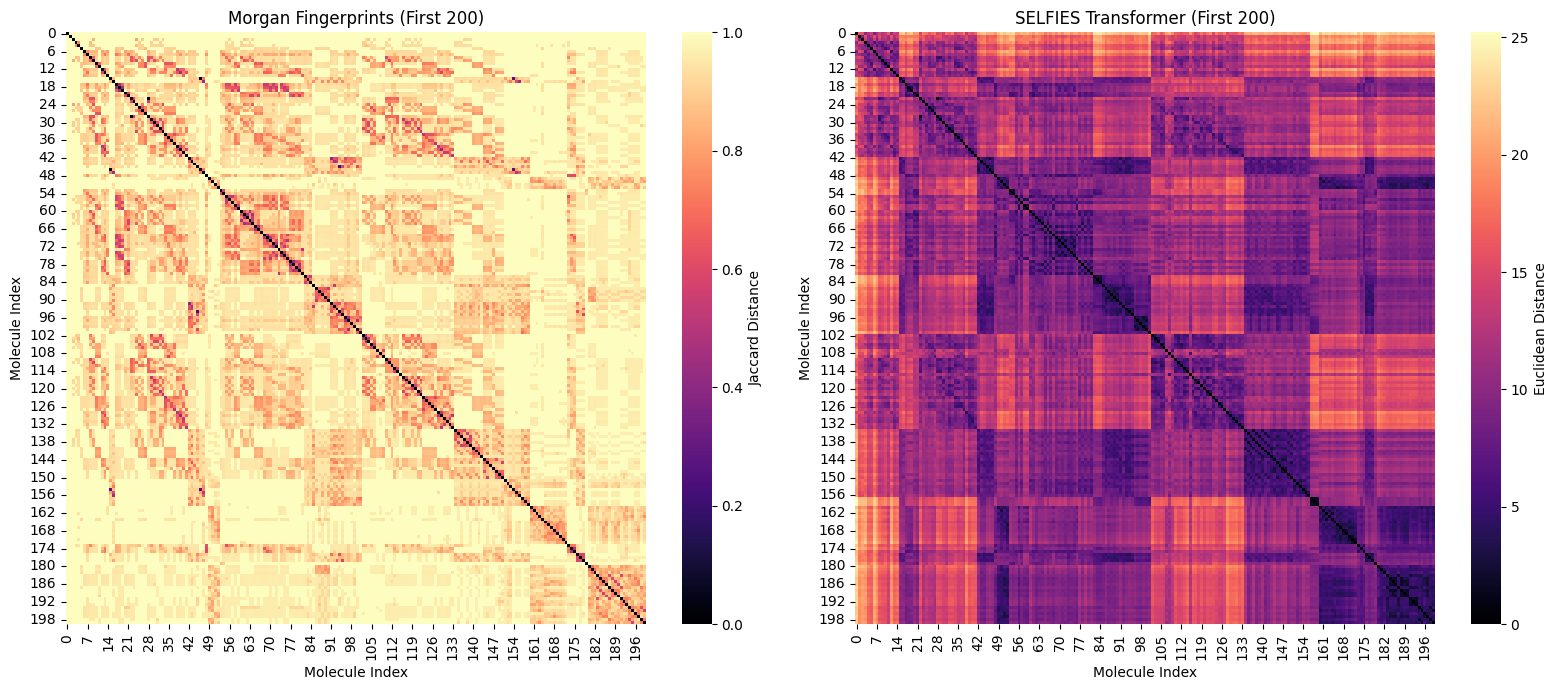

In [20]:
plot_distance_heatmaps(distance_morgan, distance_selfies, subset_size=200)

# Clustering

## Selfies strings

Preparing data matrices...
Processing Morgan Fingerprints...
Processing SELFIES One-Hot...
Processing SELFIES Transformer...


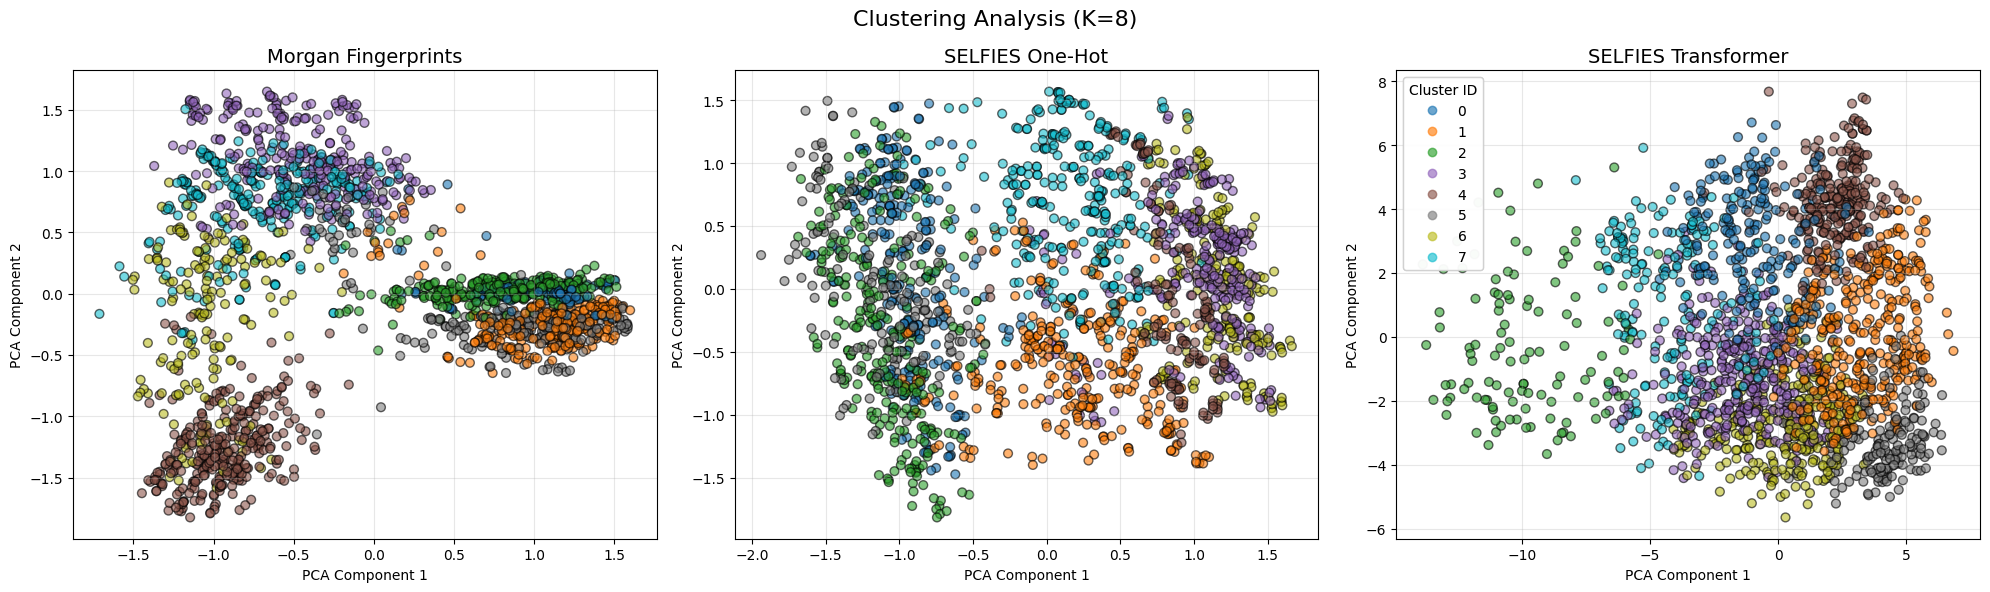

In [ ]:
import numpy as np
import polars as pl
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler

def analyze_molecular_clusters(df: pl.DataFrame, n_clusters: int = 5):
    """
    Performs K-Means clustering and PCA visualization for:
      1. Morgan Fingerprints
      2. SELFIES One-Hot Encodings
      3. SELFIES Transformer Embeddings
    """
    
    # --- 1. Data Preparation ---
    print("Preparing data matrices...")
    
    # A. Morgan Fingerprints (List of bits -> 2D Matrix)
    X_morgan = np.array(df["morgan_fingerprint"].to_list())

    # B. Transformer Embeddings (List of floats -> 2D Matrix)
    X_transformer = np.array(df["selfies_transformer"].to_list())

    # C. One-Hot Encodings (List of Lists -> Flatten to 2D Matrix)
    onehot_raw = np.array(df["selfies_onehot"].to_list())
    # Flatten the last two dimensions to make it a single vector per molecule
    n_samples, seq_len, vocab_size = onehot_raw.shape
    X_onehot = onehot_raw.reshape(n_samples, seq_len * vocab_size)

    datasets = {
        "Morgan Fingerprints": X_morgan,
        "SELFIES One-Hot": X_onehot,
        "SELFIES Transformer": X_transformer
    }

    # --- 2. Clustering & Visualization ---
    fig, axes = plt.subplots(1, 3, figsize=(20, 6))
    plt.suptitle(f"Clustering Analysis (K={n_clusters})", fontsize=16)

    for i, (name, X) in enumerate(datasets.items()):
        print(f"Processing {name}...")
        
        # Step A: Clustering (K-Means)
        kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)
        labels = kmeans.fit_predict(X)
        
        # Step B: Dimensionality Reduction (PCA) for Visualization
        pca = PCA(n_components=2)
        X_pca = pca.fit_transform(X)
        
        # Step C: Plotting
        ax = axes[i]
        scatter = ax.scatter(
            X_pca[:, 0], X_pca[:, 1], 
            c=labels, 
            cmap='tab10', 
            alpha=0.6, 
            edgecolor='k', 
            s=40
        )
        
        ax.set_title(name, fontsize=14)
        ax.set_xlabel("PCA Component 1")
        ax.set_ylabel("PCA Component 2")
        ax.grid(True, alpha=0.3)
        
        # Optional: Add legend only to the last plot to save space
        if i == 2:
            legend1 = ax.legend(*scatter.legend_elements(), title="Cluster ID")
            ax.add_artist(legend1)

    plt.tight_layout()
    plt.show()

# --- Usage Example ---
analyze_molecular_clusters(qm9.df, n_clusters=8)

In [24]:
qm9.df

mol_id,name,original_smiles,canonical_smiles,selfies,num_atoms,mu,alpha,homo,lumo,gap,r2,zpve,u0,u,h,g,cv,u0_atom,u_atom,h_atom,g_atom,A,B,C,morgan_fingerprint,selfies_onehot,selfies_transformer
str,str,str,str,str,i64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,list[i8],list[list[i64]],list[f64]
"""qm9_0""","""CH4""","""[H]C([H])([H])[H]""","""C""","""[C]""",5,0.0,13.21,-10.549854,3.186453,13.736308,35.364101,1.217682,-1101.487793,-1101.40979,-1101.384033,-1102.022949,6.469,-17.172182,-17.286823,-17.389656,-16.151918,157.711807,157.709976,157.706985,"[0, 0, … 0]","[[0, 0, … 0], [0, 0, … 1], … [0, 0, … 1]]","[1.116855, 0.998924, … 0.737373]"
"""qm9_1""","""H3N""","""[H]N([H])[H]""","""N""","""[N]""",4,1.6256,9.46,-6.993326,2.255824,9.249149,26.1563,0.934929,-1538.147705,-1538.069824,-1538.044189,-1538.666748,6.316,-12.005855,-12.082129,-12.159273,-11.246005,293.609741,293.541107,191.393967,"[0, 0, … 0]","[[0, 0, … 0], [0, 0, … 1], … [0, 0, … 1]]","[0.316447, 0.69667, … 1.264199]"
"""qm9_2""","""H2O""","""[H]O[H]""","""O""","""[O]""",3,1.8511,6.31,-7.967494,1.869422,9.836916,19.0002,0.581643,-2079.077881,-2079.000732,-2078.975098,-2079.558105,6.002,-9.240362,-9.278811,-9.330214,-8.733849,799.588135,437.90387,282.945465,"[0, 0, … 0]","[[0, 0, … 0], [0, 0, … 1], … [0, 0, … 1]]","[0.08437, 0.681181, … 0.699162]"
"""qm9_3""","""C2H2""","""[H]C#C[H]""","""C#C""","""[C][#C]""",4,0.0,16.280001,-7.741639,1.376896,9.118535,59.524799,0.730381,-2103.669434,-2103.590576,-2103.564697,-2104.186523,8.574,-16.716963,-16.792231,-16.869347,-15.862634,0.0,35.610035,35.610035,"[0, 0, … 0]","[[0, 0, … 0], [1, 0, … 0], … [0, 0, … 1]]","[0.895405, 0.401674, … 0.650952]"
"""qm9_4""","""CHN""","""[H]C#N""","""C#N""","""[C][#N]""",3,2.8937,12.99,-9.806983,0.519737,10.329442,48.747601,0.451736,-2541.866943,-2541.79834,-2541.772705,-2542.393555,6.278,-13.088188,-13.13529,-13.186666,-12.520096,0.0,44.593884,44.593884,"[0, 0, … 0]","[[0, 0, … 0], [0, 1, … 0], … [0, 0, … 1]]","[0.981024, 0.386095, … 1.052694]"
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""qm9_2010""","""C5H7NO""","""[H]C1=C([H])C([H])([H])C([H])(…","""O=C1C=CCCN1""","""[O][=C][C][=C][C][C][N][Ring1]…",14,4.175,59.880001,-6.511684,-0.854437,5.657247,680.8172,3.166589,-8833.507812,-8833.344727,-8833.319336,-8834.314453,22.622999,-60.986275,-61.363506,-61.697636,-56.969707,5.0588,2.61575,1.79821,"[0, 0, … 0]","[[0, 0, … 0], [0, 0, … 0], … [0, 0, … 1]]","[0.299405, -0.013913, … 1.102453]"
"""qm9_2011""","""C5H6O2""","""[H]C1=C([H])C([H])([H])C([H])(…","""O=C1C=CCCO1""","""[O][=C][C][=C][C][C][O][Ring1]…",13,4.8544,56.209999,-7.159316,-1.257166,5.90215,655.236389,2.820787,-9374.298828,-9374.142578,-9374.116211,-9375.104492,21.473,-58.082684,-58.426769,-58.735184,-54.355564,5.15103,2.69583,1.85565,"[0, 0, … 0]","[[0, 0, … 0], [0, 0, … 0], … [0, 0, … 1]]","[0.233892, 0.030704, … 1.002681]"
"""qm9_2012""","""C5H10NO-""","""[H][N-][C@@H]1OC([H])([H])C([H…","""[NH-][C@H]1CCCCO1""","""[NH1-1][C@H1][C][C][C][C][O][R…",16,3.2084,62.029999,-6.908971,0.634025,7.542996,719.927979,3.796587,-8865.521484,-8865.349609,-8865.324219,-8866.344727,23.990999,-65.773956,-66.218506,-66.604065,-61.192863,4.58056,2.56496,1.77558,"[0, 0, … 0]","[[0, 0, … 0], [0, 0, … 0], … [0, 0, … 1]]","[0.537106, -0.137771, … 0.598195]"
